In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy
import Corrfunc

from scipy.optimize import curve_fit
from Corrfunc.theory import xi

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [9]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [10]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [8]:
odir = "../ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk_dm = pickle.load(f)
    
print("shotnoise", Pk_dm.attrs["shotnoise"])

shotnoise 0.035287552


In [11]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [12]:
logks = np.arange(-1.5,1.5, 0.1)
ks = 10**logks

In [18]:
logks_tng = np.log10(Pk_dm["k"])
ks_tng = 10**logks_tng

(0.0, 10.0)

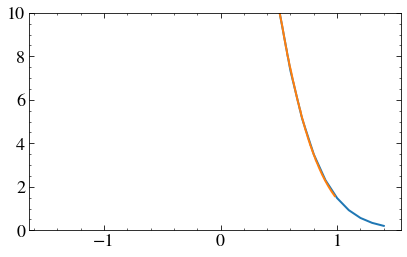

In [29]:
plt.plot(logks, Pnl(ks))
plt.plot(logks_tng, Pk_dm["power"].real)
plt.ylim(0,10)

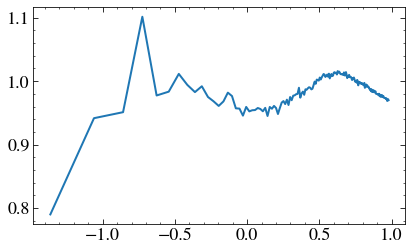

In [19]:
plt.plot(logks_tng, Pk_dm["power"].real/Pnl(ks_tng))

In [20]:
def correlation_function(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

In [23]:
r_values = np.arange(0,3,0.1)
cf_tng = correlation_function(ks_tng, Pk_dm["power"].real, r_values)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in true_divide
  


(0.0, 30.0)

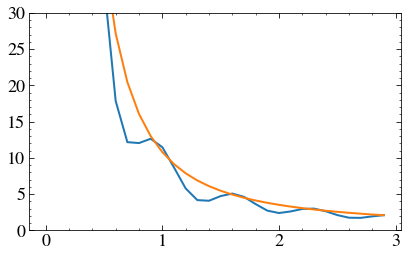

In [27]:
plt.plot(r_values, 4*cf_tng)
plt.plot(r_values, 4*cf_nl(r_values))
plt.ylim(0,30)